In [1]:
import numpy as np
import pandas as pd
import os
import json
from PIL import Image
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms
from pycocotools import mask as maskUtils
import matplotlib.pyplot as plt
import albumentations as A

c:\Users\Gordei\Desktop\Univer 2\4 sem\compviz\Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Functions for encoding and decoding
def multi_class_rle_to_array(multi_class_rle):
    """Convert a multi class RLE to a multiclass 2D arrays.

    Args:
        multi_class_rle (MultiClassRLE): a python dict with keys (size, values, counts)

    Returns:
        np.ndarray: corresponding multiclass 2D arrays
    """
    height, witdh = multi_class_rle["size"]
    mask_array = np.zeros((height * witdh), dtype=np.uint8)
    start = 0
    for val, cnt in zip(multi_class_rle["values"], multi_class_rle["counts"]):
        mask_array[start : start + cnt] = val
        start += cnt
    return mask_array.reshape((height, witdh), order='F')


def array_to_multi_class_rle(mask_array):
    """Convert a multiclass 2D arrays to a multi class RLE.

    Args:
        mask_array (MaskArray): multiclass 2D arrays

    Returns:
        MultiClassRLE:  a python dict with keys (size, values, counts)
    """
    H, W = mask_array.shape
    mask_array = mask_array.ravel(order='F')
    pad_array = mask_array
    pad_array = np.append([pad_array[0] + 1], pad_array)
    pad_array = np.append(pad_array, [pad_array[-1] + 1])
    start = np.where(pad_array[1:] != pad_array[:-1])[0]
    return {
        "size": (H, W),
        "values": tuple(mask_array[start[:-1]].tolist()),
        "counts": tuple((start[1:] - start[:-1]).tolist()),
    }

In [3]:

class CustomSegmentationDataset(Dataset):
    """
    A custom dataset class for segmentation that reads image filenames and RLE-encoded masks from a CSV file.

    Args:
        csv_file (str): Path to the CSV file that contains the data.
        image_dir (str): Directory where the images are stored.
        transform (callable, optional): Optional transformation to apply to the image.
        mask_transform (callable, optional): Optional transformation to apply to the mask.
    """
    def __init__(self, 
                 csv_file: str, 
                 image_dir: str, 
                 #processor,
                 augmentation=None):
        self.data = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.aug = augmentation
        #self.processor = processor


    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int):
        # Get the row corresponding to idx.
        row = self.data.iloc[idx]
        image_id = row["image_id"]
        mask_rle_json = row["mask"]

        # Load the image.
        img_path = os.path.join(self.image_dir, image_id)
        image = np.array(Image.open(img_path).convert("RGB")) # optionally use .convert("RGB")

        # Decode the RLE mask if provided; otherwise, assume a full background mask.
        if isinstance(mask_rle_json, str) and mask_rle_json.strip() != "":
            try:
                mask_dict = json.loads(mask_rle_json)
                mask = multi_class_rle_to_array(mask_dict)
            except Exception as e:
                raise ValueError(f"Error decoding RLE for image {image_id}: {e}")
        else:
            mask = np.zeros((image.height, image.width), dtype=np.uint8)
        
        
        if self.aug is not None:
            out   = self.aug(image=image, mask=mask)
            image = out["image"]
            mask  = out["mask"]
        
        return image, mask

In [4]:
albumentations_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1,  
                           rotate_limit=30, p=0.7),
        A.RandomResizedCrop(size=[512, 512], 
                            scale=[0.5, 1], 
                            ratio=[0.75, 1.33], p=1),
        A.RandomBrightnessContrast(0.5, 0.5, p=0.5),        
        A.HueSaturationValue(50, 30, 30, p=0.5),
        A.GaussianBlur(blur_limit=(5, 5), p=0.3),
        A.GaussNoise(std_range=[0.05, 0.2], p=0.4),
        A.ISONoise(color_shift=[0.1, 0.5], intensity=[0.1, 0.5], p=0.8),
        A.MotionBlur(blur_limit=[10, 10])
    ],
    additional_targets={"mask": "mask"},
)


dataset = CustomSegmentationDataset(
    csv_file="kuupkulgur/dataset/train.csv",
    image_dir="kuupkulgur/dataset/train",
    augmentation=albumentations_transform
)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

c:\Users\Gordei\Desktop\Univer 2\4 sem\compviz\Project\.venv\Lib\site-packages\albumentations\core\validation.py:111: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
c:\Users\Gordei\Desktop\Univer 2\4 sem\compviz\Project\.venv\Lib\site-packages\albumentations\augmentations\blur\functional.py:232: UserWarning: blur_limit: Non-zero kernel sizes must be odd. Range (10, 10) automatically adjusted to (11, 11).
  result = _ensure_odd_values(result, info.field_name)


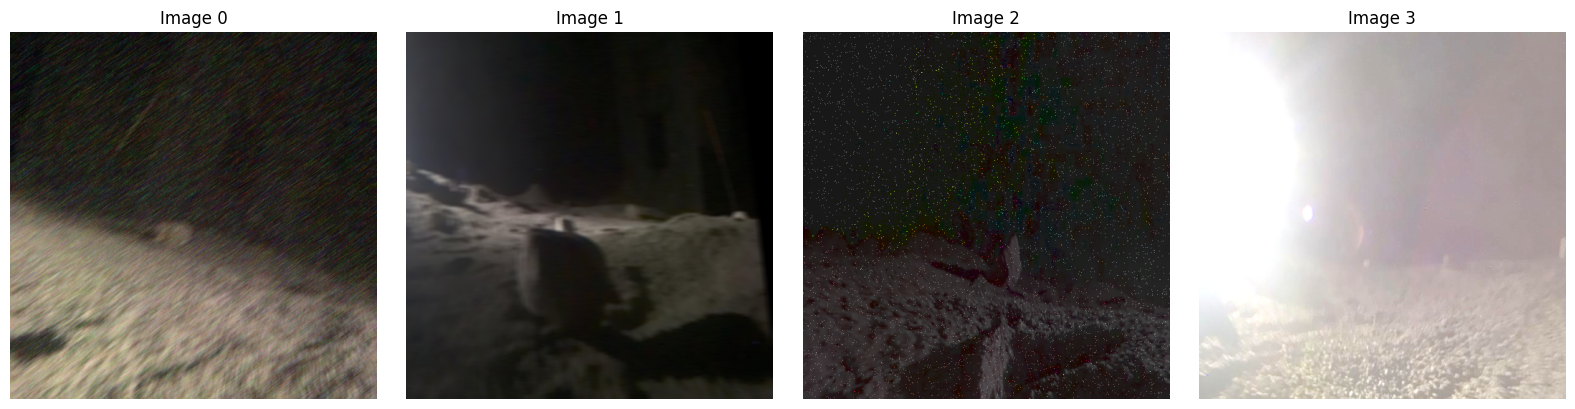

In [5]:
batch = next(iter(dataloader))
images, masks = batch
B = len(images) - 4
fig, axes = plt.subplots(1, B, figsize=(4 * B, 4))

for i in range(B):
    image = images[i]
    mask = masks[i]
    ax = axes[i]
    ax.imshow(image)
    #ax.imshow(logits[idx, 2, :, :], cmap="jet", alpha=0.5)
    #ax.imshow(mask, cmap="jet", alpha=0.5)
    ax.set_title(f"Image {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# How IoU is calculated in test. Use this for model validation
def compute_mean_iou(true_mask: np.ndarray, pred_mask: np.ndarray) -> float:
    """
    Compute the mean Intersection-over-Union (IoU) over all unique classes
    present in either mask (optionally excluding the background, here assumed to be 0).
    """
    # Exclude background (class 0) if present.
    classes = np.union1d(np.unique(true_mask), np.unique(pred_mask))
    classes = classes[classes != 0]
    if len(classes) == 0:
        return 1.0
    iou_list = []
    for c in classes:
        true_c = (true_mask == c)
        pred_c = (pred_mask == c)
        intersection = np.logical_and(true_c, pred_c).sum()
        union = np.logical_or(true_c, pred_c).sum()
        iou_c = 1.0 if union == 0 else intersection / union
        iou_list.append(iou_c)
    return np.mean(iou_list)

def compute_mean_iou_batch(true_masks, pred_masks):
    ious = []
    for i in range(len(true_masks)): 
        iou = compute_mean_iou(true_masks[i], pred_masks[i])
        ious.append(iou)
    return np.mean(ious)


# Functions for submitting to Kaggle
def create_submission_file(predictions, test_csv_path, n_of_parameters, output_csv_path):
  """
  Create a submission file for Kaggle. Make sure the order of your predictions is the same as in test.csv. Otherwise Kaggle will not be able to accurately evaluate your model.

  Args:
      predictions (list): List of predicted masks. A mask is a 2D np array, where 0 is background, 1 is crater and 2 is rock.
      test_csv_path (str): Path to the test CSV file.
      n_of_parameters (int): Number of parameters in the model. Honestly, don't cheat!
      output_csv_path (str): Path to save the submission file.
  """
  results = []
  df_test = pd.read_csv(test_csv_path)

  for i,pred_mask in enumerate(predictions):
    file_name = df_test.iloc[i]["image_id"]
    rle_encoded = array_to_multi_class_rle(pred_mask)
    results.append({
        "image_id": file_name,
        "mask": rle_encoded if rle_encoded else {'size':[pred_mask.shape[0],pred_mask.shape[1]],'counts':[],"values":[]}
    })

  # Save results to CSV
  df = pd.DataFrame(results)
  df["x"] = n_of_parameters
  # For proper CSV writing, convert the multi-class RLE dictionary to a JSON string:
  df["mask"] = df["mask"].apply(lambda x: json.dumps(x) if x != "" else "")
  df.to_csv(output_csv_path, index=False)
  print(f"Saved RLE masks to {output_csv_path}")

In [8]:
import torch, numpy as np
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
from torch.utils.data import DataLoader

In [9]:
ckpt = "nvidia/mit-b1"           
id2label = {0:"background", 1:"crater", 2: "rock"}      
#id2label = {1:"crater", 2: "rock"}      
label2id = {v:k for k,v in id2label.items()}

processor = SegformerImageProcessor.from_pretrained(ckpt, 
                                                    do_reduce_labels=False,
                                                    do_rescale=False,
                                                    size={"height": 512, "width": 512})

c:\Users\Gordei\Desktop\Univer 2\4 sem\compviz\Project\.venv\Lib\site-packages\transformers\utils\deprecation.py:172: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type'
  return func(*args, **kwargs)


In [10]:
from torch.utils.data import random_split, DataLoader

def collate(batch):
    imgs, masks = zip(*batch)
    enc = processor(list(imgs), list(masks), return_tensors='pt')
    return enc

val_fraction = 0.20                # 20 % for validation
val_len      = int(len(dataset)*val_fraction)
train_len    = len(dataset) - val_len

# reproducible shuffling
train_ds, val_ds = random_split(
        dataset,
        lengths=[train_len, val_len],
        generator=torch.Generator().manual_seed(42)  
)

val_ds.augmentations = None
train_dl = DataLoader(train_ds,
                       batch_size=6, 
                       collate_fn=collate, 
                       shuffle=True)
val_dl = DataLoader(
        val_ds,
        batch_size=6,
        collate_fn=collate,
        shuffle=False          # keep order stable during evaluation
)

In [11]:
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler

class Trainer:
    def __init__(self,
                 max_epochs, 
                 model,
                 optimizer,
                 device,
                 scaler,
                 train_loader,
                 valid_loader,
                 test_loader,
				 log_every_n_steps=50,
                 scheduler=None,
                 chkpt_dir = '.',
                 start_epoch_number=0,
    ) -> None:
        """_summary_

        Args:
            max_epochs (int): For how many epoch to train
            model (): Model to train
            optimizer (torch.optim.Optimizer): Optimizer to use for training
            device (str): Which device to train on
            train_loader (DataLoader): Traing dataloader
            valid_loader (DataLoader): Validation dataloader
            test_loader (DataLoader): Test dataloader
            log_every_n_steps (int, optional): How many batches between updating progress. Defaults to 50.
            scheduler (torch.optim.lr_scheduler.Scheduler, optional): Learning rate scheduler to use. Defaults to None.
        """
        self.model = model
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device
        self.scaler = scaler
        self.train_loader = train_loader
        self.valid_loader = valid_loader
        self.test_loader = test_loader
        self.max_epochs = max_epochs
        self.log_every_n_steps = log_every_n_steps
        self.chkpt_dir = chkpt_dir
        self.start_epoch = start_epoch_number



        self.train_losses = []
        self.train_accs = []
        self.valid_losses = []
        self.valid_accs = []
        self.valid_ious = []

        self.best_iou = -np.inf

    def train_step(self):
        self.model.train()
        running_loss = 0.0
        batch_ious = []
        pbar = tqdm(self.train_loader, desc="Training")

        for batch_idx, batch in enumerate(pbar):
            batch = {k: v.to(self.device) for k, v in batch.items()}

            self.optimizer.zero_grad()
            with torch.amp.autocast('cuda'):  
                outputs = self.model(**batch)
                loss = outputs.loss 
                
            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()               

            running_loss += loss.item()


            if batch_idx % self.log_every_n_steps == 0 or batch_idx==len(self.train_loader)-1:
                if batch_idx == 0: continue
                true_masks, pred_masks = self.to_masks(batch, outputs)
                iou = compute_mean_iou_batch(true_masks, pred_masks)
                batch_ious.append(iou)

                avg_loss = running_loss / batch_idx
                running_iou = np.mean(batch_ious)  # Averaging is valid since batch size is fixed
                pbar.set_postfix(loss=f"{avg_loss:.4f}", running_iou=f"{running_iou:.2f}")
        return avg_loss, running_iou


    def valid_step(self):
        self.model.eval()
        running_loss = 0.0
        all_true_masks, all_predicted_masks = [], []

        with torch.no_grad():
            pbar = tqdm(self.valid_loader, desc="Validation")

            for batch_idx, batch in enumerate(pbar):
                batch = {k: v.to(self.device) for k, v in batch.items()}
                with torch.amp.autocast('cuda'):  
                    outputs = self.model(**batch)
                    loss = outputs.loss     

                running_loss += loss.item()
                
                true_masks, pred_masks = self.to_masks(batch, outputs)
                all_true_masks += list(true_masks)
                all_predicted_masks += list(pred_masks)

                if batch_idx % self.log_every_n_steps == 0 or batch_idx==len(self.valid_loader)-1:
                    if batch_idx == 0: continue
                    avg_loss = running_loss / batch_idx
                    running_iou = compute_mean_iou_batch(all_true_masks, all_predicted_masks)
                    pbar.set_postfix(loss=f"{avg_loss:.4f}", running_iou=f"{running_iou:.2f}")
        
        iou = compute_mean_iou_batch(all_true_masks, all_predicted_masks)


        return avg_loss, iou

    def to_masks(self, batch, output):        
        logits = torch.nn.functional.interpolate(
            output.logits,
            size=(512, 512),
            mode="bilinear",        
            align_corners=False)
        #logits = output.logits
        
        
        labels = batch['labels']
        pred_masks = logits.argmax(dim=1) 

        labels[labels==255] = 0  # Replace background 
        labels = labels.cpu().numpy()
        pred_masks = pred_masks.cpu().numpy()

        return labels, pred_masks
    

    def train(self):
        self.model.to(self.device)
        self.train_losses = []
        self.train_ious = []
        self.valid_losses = []
        self.valid_ious = []
        self.valid_f1_scores = []

        for epoch in range(self.start_epoch, self.max_epochs):
            train_loss, train_iou = self.train_step()
            valid_loss, valid_iou = self.valid_step()
 
        
            self.train_losses.append(train_loss)
            self.train_ious.append(train_iou)
            self.valid_losses.append(valid_loss)
            self.valid_ious.append(valid_iou)

            if valid_iou > self.best_iou:
                self.best_iou = valid_iou
                self.model.save_pretrained(f'{self.chkpt_dir}/epoch_{epoch}')
                print("Saved checkpoint!")

            if self.scheduler: self.scheduler.step()
            
            print(
                f"Epoch {epoch+1}/{self.max_epochs}: "
                f"train_loss: {train_loss:.4f}, "
                f"train_acc: {train_iou:.2f}, "
                f"valid_loss: {valid_loss:.4f}, "
                f"valid_iou: {valid_iou:.2f}, "
                )
        
        return self.train_losses, self.train_accs, self.valid_losses, self.valid_accs, self.valid_f1_scores

    def test(self):
        self.model.eval()
        all_true_labels, all_predicted_labels = [], []
        with torch.no_grad():
            pbar = tqdm(self.test_loader, desc="Testing")
            for batch_idx, batch in enumerate(pbar):
                batch = {k: v.to(self.device) for k, v in batch.items()}

                outputs = self.model(**batch)
                true_masks, pred_masks = self.to_masks(batch, outputs)
                all_true_masks += list(true_masks)
                all_predicted_masks += list(pred_masks)

            final_iou = compute_mean_iou_batch(all_true_labels, all_predicted_labels)

            print(f"Test IoU: {final_iou:.2f}")

        return final_iou

    def plot_metrics(self):
        fig, ax = plt.subplots(1, 2, figsize=(15, 5))
        ax[0].plot(self.train_losses, label="train_loss", color="blue")
        ax[0].plot(self.valid_losses, label="valid_loss", linestyle="--", color="orange")
        ax[0].set_title("Losses")

        ax[1].plot(self.train_accuracies, label="train_acc", color="blue")
        ax[1].plot(self.valid_accuracies, label="valid_acc", linestyle="--", color="orange")
        ax[1].plot(self.valid_f1_scores, label="valid_macro_f1", linestyle="--", color="purple")
        ax[1].set_title("Accuracies")

        for i in range(2):
            ax[i].legend()
            ax[i].grid(0.35)
            ax[i].set_xlabel("Epochs")
        plt.show()

In [12]:
import torch
from torch.optim.lr_scheduler import SequentialLR, ConstantLR
model = SegformerForSemanticSegmentation.from_pretrained(
            ckpt, num_labels=len(id2label), id2label=id2label, label2id=label2id)
_ = model.train().cuda()
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
scaler = torch.amp.GradScaler(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)



warm_period  = ConstantLR(opt, factor=1.0,   total_iters=30)   # 30 epochs

# ── 2) drop by ×0.1 (→ 1 e-5) and stay there for the rest of training ──────────
decay_period = ConstantLR(opt, factor=0.1,   total_iters=1)    # one-shot step
hold_period  = ConstantLR(opt, factor=1.0,   total_iters=9999) # “forever”

scheduler = SequentialLR(
    opt,
    schedulers=[warm_period, decay_period, hold_period],
    milestones=[30, 31]     # indices where we switch to the next scheduler
)

max_epochs = 80
trainer = Trainer(max_epochs, model=model,
                  device=device,
                  optimizer=opt,
                  scheduler=scheduler,
                  scaler=scaler,
                  train_loader=train_dl,
                  valid_loader=val_dl, 
                  test_loader=None,
                  chkpt_dir='kuupkulgur/chkpts_b3')

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b1 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
trainer.train()

Validation: 100%|██████████| 51/51 [00:13<00:00,  3.68it/s, loss=0.1264, running_iou=0.24]


Saved checkpoint!
Epoch 1/80: train_loss: 0.2274, train_acc: 0.16, valid_loss: 0.1264, valid_iou: 0.24, 


Validation: 100%|██████████| 51/51 [00:13<00:00,  3.68it/s, loss=0.0824, running_iou=0.35]


Saved checkpoint!
Epoch 2/80: train_loss: 0.1089, train_acc: 0.36, valid_loss: 0.0824, valid_iou: 0.35, 


Validation: 100%|██████████| 51/51 [00:13<00:00,  3.67it/s, loss=0.0782, running_iou=0.39]


...

Validation: 100%|██████████| 51/51 [00:14<00:00,  3.63it/s, loss=0.0403, running_iou=0.62]


Epoch 79/80: train_loss: 0.0345, train_acc: 0.67, valid_loss: 0.0403, valid_iou: 0.62, 


Validation: 100%|██████████| 51/51 [00:14<00:00,  3.48it/s, loss=0.0350, running_iou=0.61]


Epoch 80/80: train_loss: 0.0344, train_acc: 0.71, valid_loss: 0.0350, valid_iou: 0.61, 


([0.22742264289962183,
  0.10891663771823491,
  0.08547727298913615,
  0.07469155703035027,
  0.06774172104784462,
  0.06394472829813119,
  0.05834542265586039,
  0.05714717129300727,
  0.050085161766498396,
  0.0545539839266993,
  0.04623984097327927,
  0.0538881165943671,
  0.0487219433825795,
  0.0505914917252589,
  0.046433166955772896,
  0.046763262932769736,
  0.04528229934910294,
  0.045414744069486264,
  0.046312039552053604,
  0.043467915063668594,
  0.04447241356172184,
  0.04383996695206307,
  0.044307711944537295,
  0.040761975864280424,
  0.04322227750821869,
  0.0399905730426164,
  0.04167758610496058,
  0.04206212613694739,
  0.040860004806061195,
  0.041315164320207765,
  0.04042081918917818,
  0.04305410749823003,
  0.0398547234207318,
  0.03982710927761722,
  0.04239870369489683,
  0.04076996435743231,
  0.03988329063879677,
  0.03843528539458714,
  0.03823564362500121,
  0.0400830085324769,
  0.039037325749136875,
  0.039354634983004025,
  0.03775344856111056,
  0.03

TypeError: Invalid shape (768, 3, 768) for image data

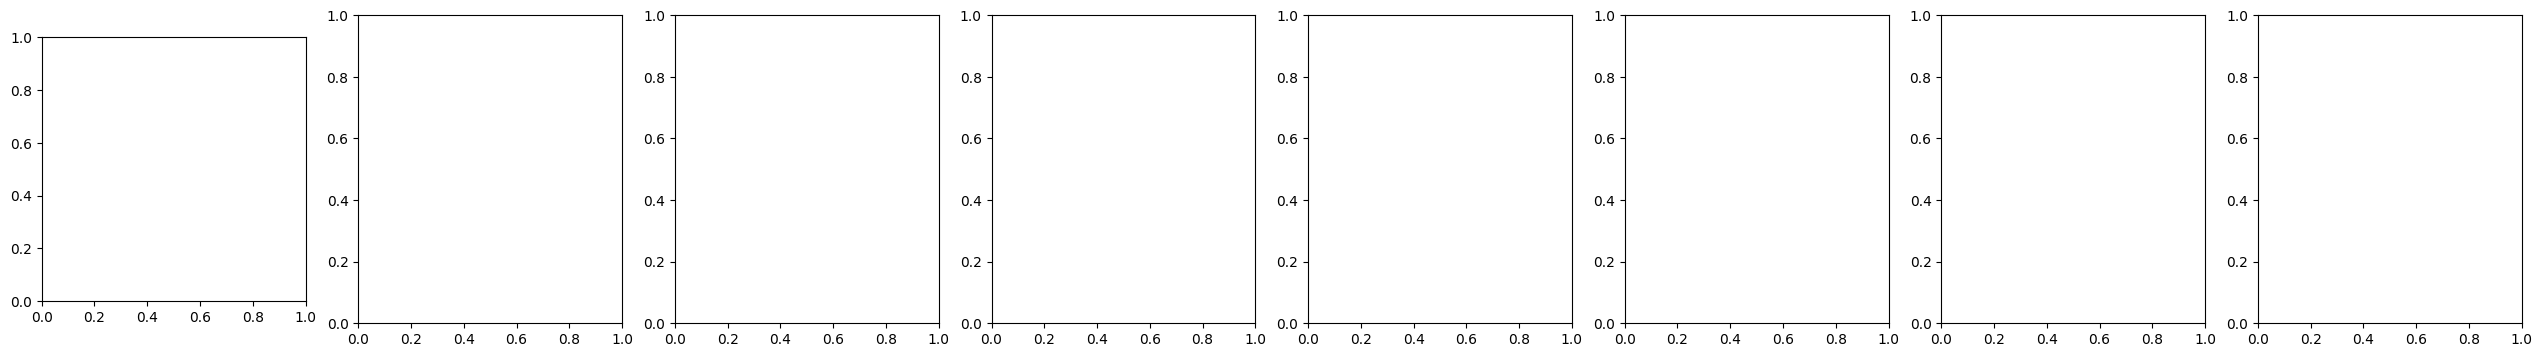

In [13]:
processor = SegformerImageProcessor.from_pretrained('nvidia/mit-b3', 
                                                    do_reduce_labels=False,
                                                    do_rescale=False,
                                                    size={"height": 512, "width": 512})

model = SegformerForSemanticSegmentation.from_pretrained('kuupkulgur/chkpts_b1/epoch_72_winner')
model.to(device)
model.eval()

dataset = CustomSegmentationDataset(
    csv_file="kuupkulgur/dataset/train.csv",
    image_dir="kuupkulgur/dataset/train",
)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

batch = next(iter(dataloader))
images, masks = batch
enc = processor(list(images), list(masks), return_tensors='pt')
model.eval()
for k in enc: enc[k] = enc[k].cuda()
with torch.no_grad(), torch.amp.autocast('cuda'):
    out = model(**enc)          # (B, C, 192, 192)


logits = torch.nn.functional.interpolate(
            out.logits,
            size=(768, 768),
            mode="bilinear",        # or "nearest" if you prefer
            align_corners=False)


#preds = np.array(preds)
preds = logits[:, :, :, :].argmax(dim=1) 
preds = preds.cpu().numpy()
logits = logits.cpu().numpy()
#print(preds)

# Convert images and masks to NumPy arrays for plotting
images_np = images.cpu().numpy()
#masks_np = masks.cpu().numpy()

images_np = np.transpose(images_np, (0, 2, 3, 1))
#masks_np = masks_np.squeeze(1)

# Plot each image with its mask overlay.
B = images_np.shape[0]
fig, axes = plt.subplots(1, B, figsize=(4 * B, 4))
if B == 1:
    axes = [axes]  # ensure axes is iterable

for idx in range(B):
    ax = axes[idx]
    ax.imshow(images_np[idx])
    #ax.imshow(logits[idx, 2, :, :], cmap="jet", alpha=0.5)
    ax.imshow(preds[idx], cmap="jet", alpha=0.5)
    ax.set_title(f"Image {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [26]:
import time
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

processor = SegformerImageProcessor.from_pretrained('nvidia/mit-b3', 
                                                    do_reduce_labels=False,
                                                    do_rescale=False,
                                                    size={"height": 512, "width": 512})

model = SegformerForSemanticSegmentation.from_pretrained('kuupkulgur/chkpts_b1/epoch_72_winner')
model.to(device)
model.eval()


test_df = pd.read_csv('kuupkulgur/dataset/test.csv')
transform = transforms.Compose([transforms.ToTensor()])

all_pred_masks = []
all_times = []
all_inf_times = []
for i, row in test_df.iterrows():
    img_id = row.image_id
    img_path = f'kuupkulgur/dataset/test/{img_id}'
    img = Image.open(img_path)
    start = time.time()
    img = transform(img)
    batch = processor([img], return_tensors='pt')
    batch = {k: v.to(device) for k, v in batch.items()}

    inf_start = time.time()
    with torch.amp.autocast('cuda'):
        outputs = model(**batch)
    inf_end = time.time()
    inf_time = inf_end-inf_start
    all_inf_times = inf_time

    logits = torch.nn.functional.interpolate(
                outputs.logits,
                size=(768, 768),
                mode="bilinear",       
                align_corners=False)

    pred_masks = logits.argmax(dim=1) 
    pred_masks = pred_masks.cpu().numpy()
    end = time.time()
    elapsed = end-start
    all_times.append(elapsed)
    all_pred_masks += list(pred_masks)

c:\Users\Gordei\Desktop\Univer 2\4 sem\compviz\Project\.venv\Lib\site-packages\transformers\utils\deprecation.py:172: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type'
  return func(*args, **kwargs)


In [27]:
print(f"Avearage total time:{np.mean(all_times)}")
print(np.mean(all_inf_times))


Avearage total time:0.07421595301941364
0.005180835723876953


In [28]:


trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
create_submission_file(np.array(all_pred_masks), "kuupkulgur/dataset/test.csv", trainable_params, 'kuupkulgur/submission_alpha3.csv')

KeyboardInterrupt: 

In [ ]:
torch.cuda.empty_cache()

In [16]:
from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()
competition = "kuup"          
submission_file = "kuupkulgur/submission_alpha3.csv"  
submission_message = "Submission Beta 3"
api.competition_submit(submission_file, submission_message, competition)

100%|██████████| 2.64M/2.64M [00:05<00:00, 463kB/s]


{"message": "Successfully submitted to DL4CV_kuupkulgur", "ref": 44822460}

In [29]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
trainable_params

13678019